### 0. Importing PyTorch and setting up device-agnostic code

In [134]:
import torch
# Imports the main PyTorch library used for tensors and deep learning operations.

from torch import nn
# Imports PyTorch’s neural network module, which provides layers and model-building tools.

torch.__version__
# Returns the installed PyTorch version so you can verify your environment.


'2.12.0+cpu'

In [135]:
# Set up device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
# Chooses GPU ("cuda") if available, otherwise defaults to CPU for safe, portable execution.

device
# Displays which device is being used so you can verify your runtime environment.


'cpu'

In [136]:
!nvidia-smi
# Runs the system command to display GPU status, driver info, and active CUDA processes.


Sun Jul  5 11:42:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P8             14W /   95W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [137]:
import requests 
# Imports the requests library to download files over HTTP.

import zipfile 
# Imports zipfile to read and extract ZIP archives.

from pathlib import Path 
# Imports Path for clean, OS‑agnostic filesystem path handling.

data_path = Path("data/")
# Creates a Path object pointing to the "data/" directory.

image_path = data_path / "pizza_steak_sushi"
# Defines the folder where the dataset should live.

if image_path.is_dir():
    print(f"{image_path} directory exists.")
    # Confirms the dataset directory already exists.
else: 
    print(f"Did not find {image_path} directory, creating one....")
    # Alerts that the directory is missing and will be created.
    image_path.mkdir(parents=True, exist_ok=True)
    # Creates the directory (including parents) if it doesn’t exist.

    with open(data_path / "pizza_steak_sushi.zip", "wb") as f: 
        # Opens a local ZIP file in write‑binary mode to save the download.
        requests = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        # Downloads the pizza/steak/sushi dataset ZIP from GitHub.
        print("Downloading pizza, steak, sushi data...")
        # Notifies that the dataset is being downloaded.
        f.write(requests.content)
        # Writes the downloaded ZIP file contents to disk.

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref: 
        # Opens the downloaded ZIP file for reading.
        print("Unzipping pizza, steak, sushi data.....")
        # Notifies that extraction is starting.
        zip_ref.extractall(image_path)
        # Extracts all files from the ZIP into the dataset directory.


data\pizza_steak_sushi directory exists.


In [138]:
image_path

WindowsPath('data/pizza_steak_sushi')

### 2. Become one with the data (data preparation)

In [139]:
import os 
# Imports the os module to interact with the operating system’s directory structure.

def walk_through_dir(dir_path): 
    # Defines a function that prints how many folders and files exist in each subdirectory.
    for dirpath, dirnames, filenames in os.walk(dir_path):
        # Iterates through all directories, subdirectories, and files starting at dir_path.
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")
        # Prints the count of subdirectories and files for the current directory path.


In [140]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [141]:
# Setup train and testing paths 
train_dir = image_path / "train"
# Points to the folder containing all training images.

test_dir = image_path / "test"
# Points to the folder containing all testing images.

train_dir, test_dir
# Displays both paths so you can verify they were constructed correctly.


(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### 2.1 Visualize an image

Random image path: data\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


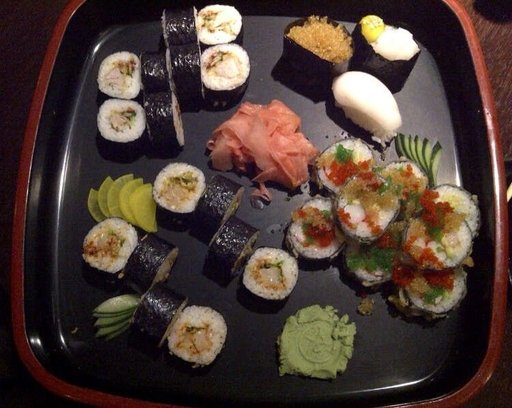

In [142]:
import random
# Imports Python’s random module for selecting random items.

from PIL import Image
# Imports PIL’s Image class to open and inspect image files.

# Set seed
random.seed(42)  # <- try changing this and see what happens
# Sets the random seed so results are reproducible across runs.

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))
# Collects all .jpg images inside class folders within train/test directories.

# 2. Get random image path
random_image_path = random.choice(image_path_list)
# Selects one random image from the dataset.

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
# Extracts the class label by reading the folder name containing the image.

# 4. Open image
img = Image.open(random_image_path)
# Loads the selected image into memory using PIL.

# 5. Print metadata
print(f"Random image path: {random_image_path}")
# Prints the full file path of the randomly selected image.

print(f"Image class: {image_class}")
# Prints the class label (pizza, steak, or sushi).

print(f"Image height: {img.height}")
# Prints the image height in pixels.

print(f"Image width: {img.width}")
# Prints the image width in pixels.

img
# Displays the image object so Jupyter/Colab will render it visually.


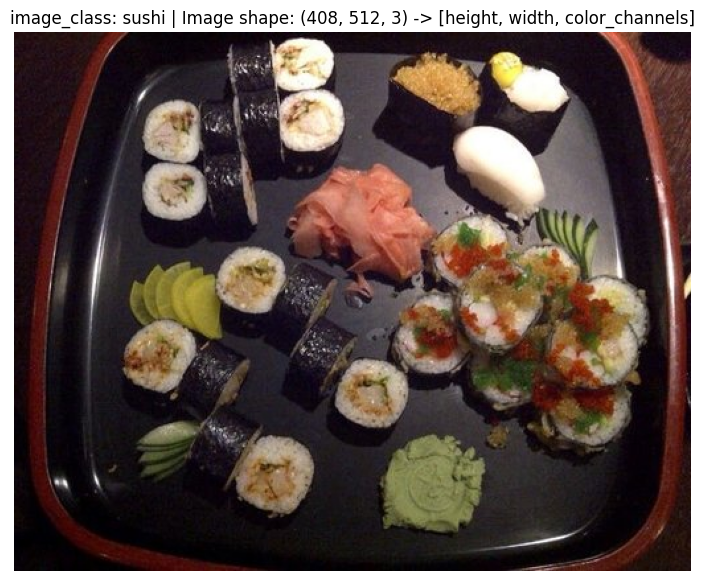

In [143]:
import numpy as np 
# Imports NumPy to convert the PIL image into a numerical array.

import matplotlib.pyplot as plt 
# Imports Matplotlib for plotting and visualizing the image.

img_as_array = np.asarray(img)
# Converts the PIL image into a NumPy array so Matplotlib can display it.

plt.figure(figsize=(10,7))
# Creates a new figure with a defined width and height for clearer visualization.

plt.imshow(img_as_array)
# Displays the image array as a plot.

plt.title(f"image_class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
# Adds a title showing the class and the image’s shape (H, W, C).

plt.axis(False);
# Hides axis ticks and labels for a cleaner image display.


In [144]:
img_as_array

array([[[33, 13, 15],
        [30, 10, 12],
        [30, 10, 12],
        ...,
        [23, 14, 19],
        [21, 12, 17],
        [20, 11, 16]],

       [[35, 15, 17],
        [32, 12, 14],
        [31, 11, 13],
        ...,
        [21, 12, 17],
        [19, 10, 15],
        [19, 10, 15]],

       [[34, 15, 17],
        [31, 12, 14],
        [30, 11, 13],
        ...,
        [19,  9, 17],
        [18,  8, 16],
        [18,  8, 16]],

       ...,

       [[11,  6, 12],
        [11,  6, 12],
        [11,  6, 12],
        ...,
        [33, 19, 18],
        [33, 19, 19],
        [31, 17, 17]],

       [[ 8,  3,  9],
        [ 9,  4, 10],
        [ 9,  4, 10],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [27, 11, 11]],

       [[ 4,  0,  5],
        [ 5,  0,  6],
        [ 6,  1,  7],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [25,  9,  9]]], shape=(408, 512, 3), dtype=uint8)

In [145]:
import torch 
# Imports the main PyTorch library for tensors and deep learning operations.

from torch.utils.data import DataLoader
# Imports DataLoader, which efficiently batches and loads data during training/testing.

from torchvision import transforms, datasets
# Imports torchvision tools: transforms for preprocessing and datasets for loading image folders.


In [146]:
data_transform = transforms.Compose([
    # Creates a pipeline of image transformations applied in sequence.

    transforms.Resize(size=(64,64)),
    # Resizes every image to 64×64 pixels for consistent model input size.

    transforms.RandomHorizontalFlip(p=0.5),
    # Randomly flips the image horizontally with 50% probability to add augmentation.

    transforms.ToTensor()
    # Converts the PIL image (H×W×C) into a PyTorch tensor (C×H×W) scaled to [0,1].
])


In [147]:
data_transform(img)

tensor([[[0.1294, 0.1373, 0.1412,  ..., 0.0863, 0.0824, 0.0824],
         [0.1255, 0.1373, 0.1412,  ..., 0.0902, 0.0902, 0.0902],
         [0.1294, 0.1412, 0.1333,  ..., 0.1059, 0.0980, 0.1137],
         ...,
         [0.0157, 0.0196, 0.0157,  ..., 0.1294, 0.1373, 0.1412],
         [0.0275, 0.0275, 0.0275,  ..., 0.1255, 0.1373, 0.1333],
         [0.0314, 0.0314, 0.0275,  ..., 0.1137, 0.1294, 0.1255]],

        [[0.0588, 0.0588, 0.0667,  ..., 0.0392, 0.0431, 0.0431],
         [0.0588, 0.0549, 0.0667,  ..., 0.0392, 0.0431, 0.0353],
         [0.0510, 0.0627, 0.0627,  ..., 0.0471, 0.0471, 0.0392],
         ...,
         [0.0039, 0.0078, 0.0078,  ..., 0.0667, 0.0667, 0.0667],
         [0.0118, 0.0118, 0.0118,  ..., 0.0706, 0.0706, 0.0667],
         [0.0118, 0.0157, 0.0196,  ..., 0.0667, 0.0667, 0.0667]],

        [[0.0667, 0.0667, 0.0667,  ..., 0.0706, 0.0706, 0.0745],
         [0.0784, 0.0784, 0.0863,  ..., 0.0941, 0.0902, 0.0863],
         [0.0824, 0.0863, 0.0941,  ..., 0.0941, 0.1059, 0.

In [148]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [149]:
data_transform(img).dtype

torch.float32

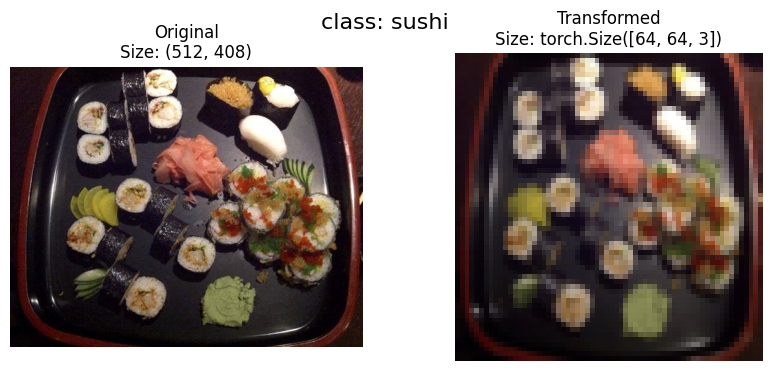

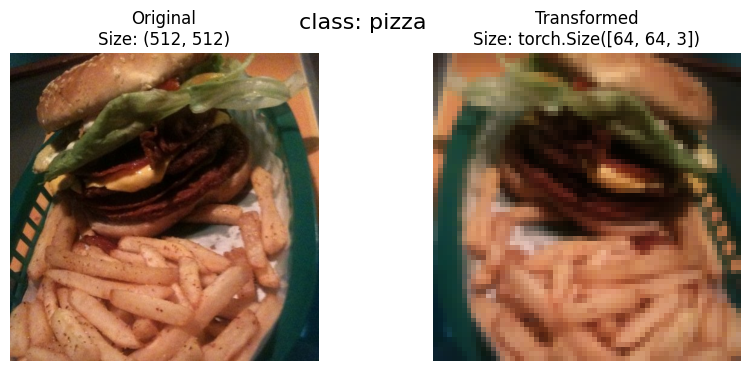

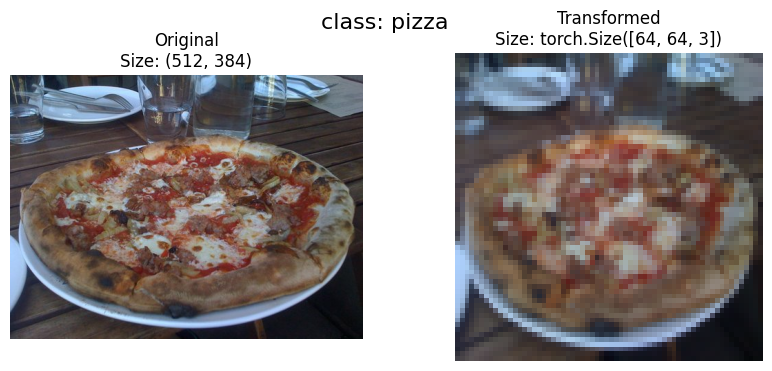

In [150]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    # Defines a function that visualizes original vs transformed versions of random images.

    random.seed(seed)
    # Sets the random seed so the same images are chosen each run.

    random_image_paths = random.sample(image_paths, k=n)
    # Selects n random image paths from the dataset.

    for image_path in random_image_paths:
        # Loops through each randomly selected image.

        with Image.open(image_path) as f:
            # Opens the image file using PIL.

            fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            # Creates a figure with two side‑by‑side subplots for comparison.

            ax[0].imshow(f)
            # Displays the original image.

            ax[0].set_title(f"Original\nSize: {f.size}")
            # Shows the original image’s dimensions.

            ax[0].axis("off")
            # Removes axis ticks for a cleaner display.

            transformed_image = transform(f).permute(1, 2, 0)
            # Applies the transform pipeline, then permutes tensor to H×W×C for plotting.

            ax[1].imshow(transformed_image)
            # Displays the transformed image.

            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            # Shows the transformed image’s dimensions.

            ax[1].axis("off")
            # Removes axis ticks for a cleaner display.

            fig.suptitle(f"class: {image_path.parent.stem}", fontsize=16)
            # Adds a title showing the image’s class (pizza, steak, or sushi).

            plt.show()
            # Renders the figure.

plot_transformed_images(image_path_list, transform=data_transform, n=3)
# Calls the function to visualize 3 randomly selected transformed images.


### 4. Option 1: Loading Image Data Using ImageFolder

In [151]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
# Imports torchvision’s dataset utilities, including ImageFolder for loading labeled image folders.

train_data = datasets.ImageFolder(
    root=train_dir,               # target folder of images
    transform=data_transform,     # transforms to perform on data (images)
    target_transform=None         # transforms to perform on labels (if necessary)
)
# Creates the training dataset by reading images from train_dir and applying the transform pipeline.

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform
)
# Creates the testing dataset using the same transform pipeline for consistency.

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")
# Prints dataset objects so you can verify they loaded correctly.


Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [152]:
class_dict = train_data.class_to_idx
class_dict 

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [153]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [154]:
len(train_data), len(test_data)

(225, 75)

In [155]:
train_data.samples 

[('data\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1033251.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1044789.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1089334.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1105700.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\12301.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1285298.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\138855.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1412034.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1524655.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1572608.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1633289.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1649276.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1654444.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1660415.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1899785.jpg', 0),
 ('data\\pizza_steak_sushi\\train\\pizza\\1

In [156]:
train_data.targets

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

In [157]:
img, label = train_data[0][0], train_data[0][1]
# Retrieves the first training sample: img is the tensor, label is its class index.

print(f"Image tensor:\n{img}")
# Prints the raw image tensor values.

print(f"Image shape: {img.shape}")
# Shows the tensor dimensions (C × H × W).

print(f"Image datatype: {img.dtype}")
# Displays the tensor’s data type, typically torch.float32 after ToTensor().

print(f"Image label: {label}")
# Prints the numeric class label (e.g., 0 = pizza, 1 = steak, 2 = sushi).

print(f"Label datatype: {type(label)}")
# Shows the Python type of the label (usually int).


Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [158]:
class_names = train_data.classes


Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


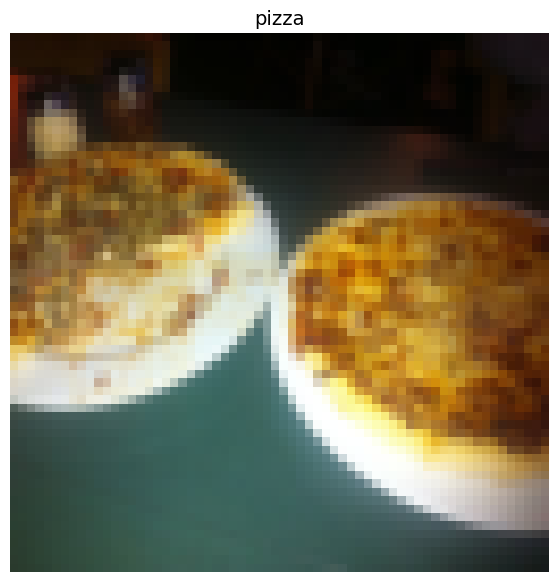

In [159]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)
# Converts the tensor from [channels, height, width] → [height, width, channels] for plotting.

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
# Shows the original PyTorch tensor layout (C × H × W).

print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")
# Shows the permuted layout (H × W × C) required by Matplotlib.

# Plot the image
plt.figure(figsize=(10, 7))
# Creates a large figure for clear visualization.

plt.imshow(img.permute(1, 2, 0))
# Displays the permuted image so Matplotlib can interpret the color channels correctly.

plt.axis("off")
# Removes axis ticks and labels for a cleaner image display.

plt.title(class_names[label], fontsize=14);
# Adds the class name (pizza, steak, or sushi) as the plot title.


In [160]:
import os 
os.cpu_count()

12

In [161]:
from torch.utils.data import DataLoader 
# Imports DataLoader, which batches and loads dataset samples efficiently during training/testing.

train_dataloader = DataLoader(
    dataset=train_data,   # the training dataset created with ImageFolder
    batch_size=1,         # loads one image per batch (you can increase this later)
    num_workers=1,        # number of subprocesses used for data loading
    shuffle=True          # shuffles training data each epoch for better learning
)
# Creates the training dataloader that feeds batches of transformed images to the model.

test_dataloader = DataLoader(
    dataset=test_data,    # the testing dataset
    batch_size=1,         # loads one image per batch
    num_workers=1,        # number of subprocesses used for data loading
    shuffle=False         # keeps test data order consistent for evaluation
)
# Creates the testing dataloader for deterministic evaluation.

train_dataloader, test_dataloader
# Displays both dataloaders so you can verify they were created successfully.


(<torch.utils.data.dataloader.DataLoader at 0x2c73d5e68d0>,
 <torch.utils.data.dataloader.DataLoader at 0x2c73eb292e0>)

In [162]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [163]:
len(train_data), len(test_data)

(225, 75)

In [164]:
img, label = next(iter(train_dataloader))
# Retrieves the first batch from the training dataloader: img is the tensor batch, label is the batch of labels.

print(f"Image shape: {img.shape}")
# Prints the shape of the image batch (batch_size, channels, height, width).

print(f"Label shape: {label.shape}")
# Prints the shape of the label batch (batch_size).


Image shape: torch.Size([1, 3, 64, 64])
Label shape: torch.Size([1])


## 5. Option 2: Loading Image Data with a Custom `Dataset`

In [165]:
import os 
# Imports the os module for interacting with filesystem paths and directories.

import pathlib 
# Imports pathlib for object‑oriented path handling (Path objects).

import torch 
# Imports PyTorch, the core deep learning framework.

from PIL import Image 
# Imports PIL’s Image class to load and manipulate image files.

from torch.utils.data import Dataset 
# Imports the base Dataset class so you can create custom PyTorch datasets.

from torchvision import transforms 
# Imports torchvision transforms for preprocessing images.

from typing import Tuple, Dict, List
# Imports type hints to make your custom dataset code clearer and more maintainable.


In [166]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

In [167]:
target_directory = train_dir 
# Points to the training directory so you can inspect its structure.

print(f"Target directory: {target_directory}")
# Prints the path to confirm which directory you're analyzing.

class_names_found = sorted([entry.name for entry in list(os.scandir(image_path/"train"))])
# Scans the train/ folder, collects each subdirectory name (pizza, steak, sushi), and sorts them alphabetically.

print(f"Class names found: {class_names_found}")
# Prints the discovered class names so you can verify the dataset structure.


Target directory: data\pizza_steak_sushi\train
Class names found: ['pizza', 'steak', 'sushi']


In [168]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    # Defines a function that returns class names and a mapping from class → index.

    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    # Scans the directory, collects only subfolders (each representing a class), and sorts them alphabetically.

    if not classes: 
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")
        # Raises an error if no class folders are found—prevents silent failures.

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    # Creates a dictionary mapping each class name to a unique integer index.

    return classes, class_to_idx
    # Returns both the list of class names and the class→index mapping.


In [169]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

In [170]:
from torch.utils.data import Dataset 
# Imports the base PyTorch Dataset class so you can build a custom dataset.

class ImageFolderCustom(Dataset):
    # Creates a custom dataset that mimics torchvision.datasets.ImageFolder.

    def __init__(self, targ_dir: str, transform=None) -> None: 
        # Initializes the dataset with a target directory and optional transforms.

        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        # Collects all image file paths inside class subfolders.

        self.transform = transform 
        # Stores the transform pipeline to apply to each image.

        self.classes, self.class_to_idx = find_classes(targ_dir)
        # Finds class names and builds a class→index mapping.

    def load_image(self, index: int) -> Image.Image: 
        "Open an image via a path and returns it."
        # Helper method to load a single image from disk.

        image_path = self.paths[index]
        # Retrieves the file path for the requested index.

        return Image.open(image_path)
        # Opens and returns the PIL image.

    def __len__(self) -> int: 
        # Returns the total number of images in the dataset.

        return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        # Retrieves one sample: transformed image tensor + class index.

        img = self.load_image(index)
        # Loads the image at the given index.

        class_name = self.paths[index].parent.name 
        # Extracts the class name from the parent folder.

        class_idx = self.class_to_idx[class_name]
        # Converts the class name into its numeric label.

        if self.transform:
            return self.transform(img), class_idx
            # Applies transforms and returns the tensor + label.
        else: 
            return img, class_idx
            # Returns the raw PIL image + label if no transforms were provided.


In [171]:
img, label = train_data[0]

In [172]:
img, label 

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [173]:
train_transforms = transforms.Compose([
    # Transformation pipeline applied to training images.

    transforms.Resize((64,64)),
    # Resizes every image to a fixed 64×64 resolution.

    transforms.RandomHorizontalFlip(p=0.5),
    # Adds augmentation by flipping images horizontally with 50% probability.

    transforms.ToTensor()
    # Converts the PIL image into a PyTorch tensor scaled to [0,1].
])

test_transforms = transforms.Compose([
    # Transformation pipeline applied to test images (no augmentation).

    transforms.Resize((64,64)),
    # Ensures test images match the model’s expected input size.

    transforms.ToTensor()
    # Converts the PIL image into a PyTorch tensor.
])


In [174]:
train_data_custom = ImageFolderCustom(
    targ_dir=train_dir, 
    transform=train_transforms
)
# Creates a custom training dataset using your ImageFolderCustom class
# and applies the training transform pipeline (resize + flip + tensor).

test_data_custom = ImageFolderCustom(
    targ_dir=test_dir,
    transform=test_transforms
)
# Creates a custom testing dataset with deterministic transforms
# (resize + tensor, no augmentation).

train_data_custom, test_data_custom
# Displays both dataset objects so you can verify they were created successfully.


(<__main__.ImageFolderCustom at 0x2c7446a3260>,
 <__main__.ImageFolderCustom at 0x2c74474d340>)

In [175]:
len(train_data), len(train_data_custom)

(225, 225)

In [176]:
len(test_data), len(test_data_custom)

(75, 75)

In [177]:
train_data_custom.classes 


['pizza', 'steak', 'sushi']

In [178]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [179]:
print((len(train_data_custom)==len(train_data)) & (len(test_data_custom)==len(test_data)))
# Checks whether the custom dataset and ImageFolder dataset have the same number of images
# for both train and test splits. Returns True if both match.

print(train_data_custom.classes == train_data.classes)
# Verifies that both datasets discovered the exact same class names.

print(train_data_custom.class_to_idx == train_data.class_to_idx)
# Confirms that both datasets produced the same class→index mapping.


True
True
True


### 5.3 Create a function to display random images

In [180]:
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int =10,
                          display_shape: bool = True, 
                          seed: int = None):
    # Defines a utility function to visualize up to 10 random images from a dataset.

    if n > 10: 
        n = 10
        display_shape = False 
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
        # Caps n at 10 to prevent overcrowded plots and disables shape display.

    if seed: 
        random.seed(seed)
        # Sets a random seed for reproducible image selection.

    random_samples_idx = random.sample(range(len(dataset)), k=n)
    # Selects n random indices from the dataset.

    plt.figure(figsize=(16,8))
    # Creates a wide figure to fit up to 10 images side‑by‑side.

    for i, targ_sample in enumerate(random_samples_idx):
        # Iterates through each randomly selected index.

        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
        # Retrieves the image tensor and its class label.

        targ_image_adjust = targ_image.permute(1,2,0)
        # Converts the tensor from [C,H,W] → [H,W,C] for Matplotlib.

        plt.subplot(1,n, i+1)
        # Creates a subplot for each image.

        plt.imshow(targ_image_adjust)
        # Displays the image.

        plt.axis("off")
        # Removes axes for a cleaner visualization.

        if classes: 
            title = f"class: {classes[targ_label]}"
            # Sets the title to the class name.

            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
                # Optionally adds the image shape.

        plt.title(title)
        # Applies the final title to the subplot.


In [181]:
random.sample(range(len(train_data_custom)), k=10)

[62, 57, 35, 188, 26, 173, 189, 139, 22, 151]

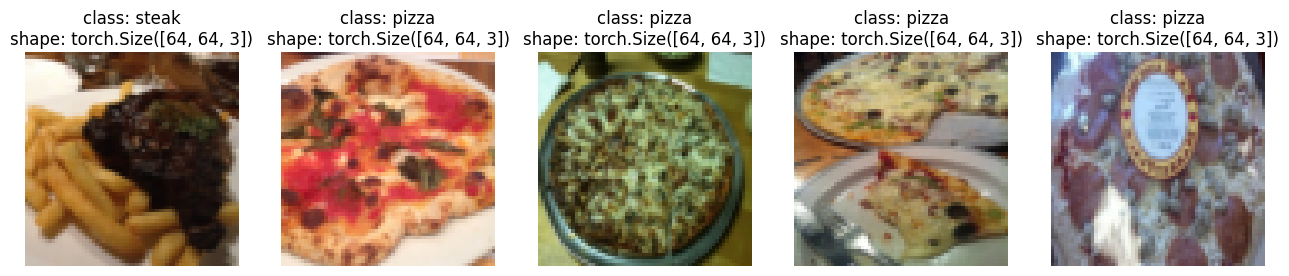

In [182]:
display_random_images(train_data, n=5, classes=class_names, seed=None)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


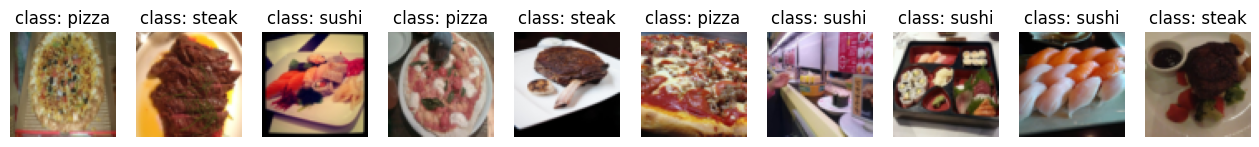

In [183]:
display_random_images(train_data_custom, n=12, classes=class_names,
                      seed=None)

In [184]:
from torch.utils.data import DataLoader 
# Imports DataLoader to batch, shuffle, and stream dataset samples efficiently.

train_dataloader_custom = DataLoader(
    dataset=train_data_custom,  # your custom training dataset
    batch_size=1,               # loads one image per batch
    num_workers=0,              # uses the main process for loading (safe for Windows/Jupyter)
    shuffle=True                # shuffles training samples each epoch for better learning
)
# Creates the training dataloader for your custom dataset.

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,   # your custom testing dataset
    batch_size=1,               # loads one image per batch
    num_workers=0,              # avoids multiprocessing issues in notebooks
    shuffle=False               # keeps test order deterministic
)
# Creates the testing dataloader for your custom dataset.

train_dataloader_custom, test_dataloader_custom
# Displays both dataloaders so you can verify they were created successfully.


(<torch.utils.data.dataloader.DataLoader at 0x2c73efaa000>,
 <torch.utils.data.dataloader.DataLoader at 0x2c73fc97a10>)

In [185]:
img_custom, label_custom = next(iter(train_dataloader_custom))
# Retrieves the first batch from the custom training dataloader:
# img_custom is the image tensor batch, label_custom is the label batch.

print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
# Shows the full 4‑D tensor layout that PyTorch uses for batched images.

print(f"Label shape: {label_custom.shape}")
# Shows the label batch shape (batch_size).


Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## 6. Other forms of transforms (data augmentation)

In [186]:
from torchvision import transforms 
# Imports torchvision’s transform utilities for preprocessing and augmentation.

train_transforms = transforms.Compose([
    # Transformation pipeline applied to training images.

    transforms.Resize((224,224)),
    # Resizes every image to 224×224 — the standard input size for many CNNs (e.g., ResNet).

    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    # Applies lightweight, randomized augmentation from a wide set of operations
    # (rotation, color jitter, sharpness, etc.) with 31 magnitude bins.

    transforms.ToTensor()
    # Converts the augmented PIL image into a PyTorch tensor scaled to [0,1].
])

test_transforms = transforms.Compose([
    # Deterministic preprocessing pipeline for test images.

    transforms.Resize((224, 224)),
    # Ensures test images match the model’s expected input size.

    transforms.ToTensor()
    # Converts the PIL image into a PyTorch tensor.
])


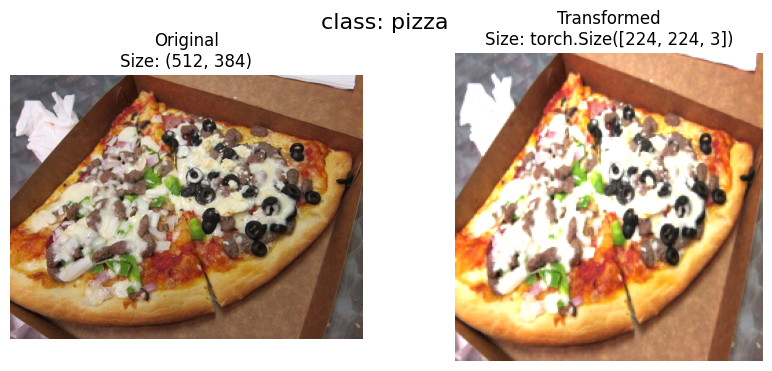

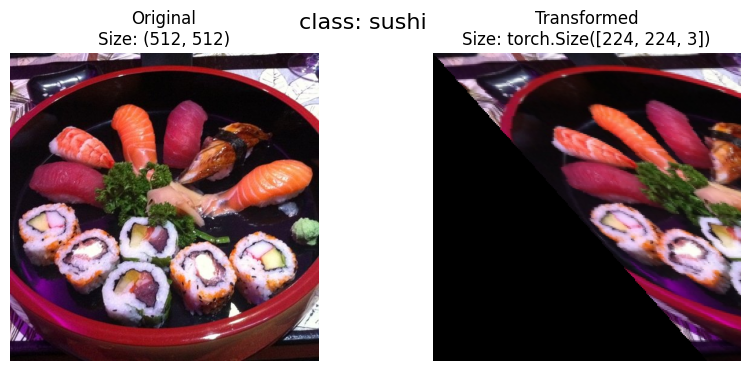

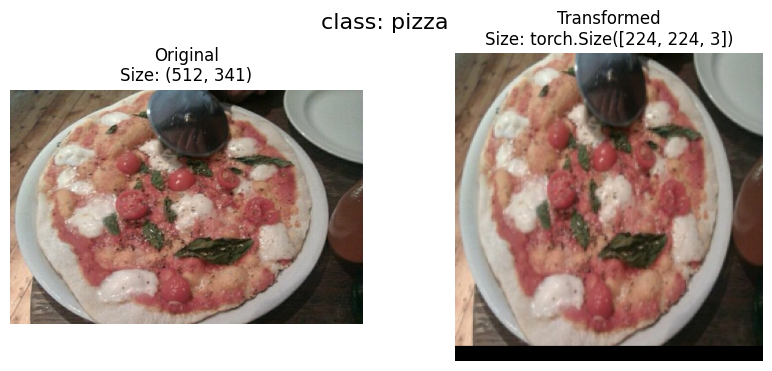

In [187]:
# Get all image paths 
image_path_list = list(image_path.glob("*/*/*.jpg"))
# Recursively collects every .jpg file inside train/test → class folders.

plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)
# Visualizes 3 randomly selected images after applying the training transform pipeline.
# Uses your custom plotting function to show original vs transformed samples.


## 7. Model 0: TinyVGG without data augmentation

### 7.1 Creating transforms and loading data for Model 0

In [188]:
simple_transform = transforms.Compose([
    # A minimal preprocessing pipeline for quick experiments or debugging.

    transforms.Resize((64,64)),
    # Resizes every image to a small, fixed 64×64 resolution.

    transforms.ToTensor(),
    # Converts the PIL image into a PyTorch tensor scaled to [0,1].
])


In [189]:
# 1. Load and transform data
from torchvision import datasets
# Imports torchvision’s dataset utilities, including ImageFolder.

train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
# Loads training images from train_dir and applies simple_transform to each sample.

test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)
# Loads testing images from test_dir with the same simple preprocessing pipeline.


# 2. Turn data into DataLoaders
import os
from torch.utils.data import DataLoader
# Imports DataLoader to batch and stream dataset samples efficiently.

# Setup batch size and number of workers 
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")
# Uses all available CPU cores for parallel data loading.


# Create DataLoader's
train_dataloader_simple = DataLoader(
    train_data_simple, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS
)
# Creates the training dataloader with shuffling and parallel workers.

test_dataloader_simple = DataLoader(
    test_data_simple, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS
)
# Creates the testing dataloader with deterministic ordering.

train_dataloader_simple, test_dataloader_simple
# Displays both dataloaders for verification.


Creating DataLoader's with batch size 32 and 12 workers.


(<torch.utils.data.dataloader.DataLoader at 0x2c74461a270>,
 <torch.utils.data.dataloader.DataLoader at 0x2c7446a13a0>)

In [190]:
NUM_WORKERS

12

### 7.2 Create TinyVGG model class

In [191]:
class TinyVGG(nn.Module):
    # Defines a small VGG‑style convolutional neural network.

    def __init__(self, input_shape: int, hidden_units: int, output_shape:int) -> None:
        super().__init__()
        # Initializes the nn.Module parent class.

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            # First convolution: preserves spatial size because padding=1.

            nn.ReLU(),
            # Non‑linear activation.

            nn.MaxPool2d(kernel_size=2,
                         stride=2)
            # Downsamples H×W by a factor of 2.
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            # Second conv: preserves spatial size.

            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            # Third conv: also preserves spatial size.

            nn.MaxPool2d(2)
            # Downsamples H×W by another factor of 2.
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Flattens the feature map into a single vector.

            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
            # Fully connected layer mapping flattened features → class logits.
        )

    def forward(self, x:torch.Tensor):
        # Defines the forward pass.

        x = self.conv_block_1(x)
        # Apply first conv block.

        x = self.conv_block2(x)
        # Apply second conv block.

        x = self.classifier(x)
        # Flatten + linear classifier.

        return x


In [192]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, 
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [193]:
# Get one batch
img_batch, label_batch = next(iter(train_dataloader_simple))

# Extract a single sample
img_single = img_batch[0].unsqueeze(0)   # [1, C, H, W]
label_single = label_batch[0]

# Run inference
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# Outputs
print(f"Single image shape: {img_single.shape}\n")
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Predicted label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")


Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[ 0.0169,  0.0418, -0.0354]])

Output prediction probabilities:
tensor([[0.3362, 0.3447, 0.3191]])

Predicted label:
tensor([1])

Actual label:
1


In [194]:
model_0(img_batch.to(device))

tensor([[ 0.0169,  0.0418, -0.0354],
        [ 0.0129,  0.0407, -0.0306],
        [ 0.0175,  0.0394, -0.0304],
        [ 0.0109,  0.0356, -0.0321],
        [ 0.0172,  0.0459, -0.0394],
        [ 0.0134,  0.0505, -0.0305],
        [ 0.0148,  0.0571, -0.0373],
        [ 0.0170,  0.0527, -0.0341],
        [ 0.0214,  0.0463, -0.0410],
        [ 0.0159,  0.0417, -0.0272],
        [ 0.0169,  0.0426, -0.0288],
        [ 0.0217,  0.0341, -0.0360],
        [ 0.0103,  0.0515, -0.0216],
        [ 0.0244,  0.0567, -0.0204],
        [ 0.0167,  0.0511, -0.0307],
        [ 0.0147,  0.0414, -0.0313],
        [ 0.0178,  0.0429, -0.0324],
        [ 0.0200,  0.0489, -0.0248],
        [ 0.0056,  0.0451, -0.0251],
        [ 0.0135,  0.0502, -0.0275],
        [ 0.0267,  0.0559, -0.0372],
        [ 0.0133,  0.0493, -0.0280],
        [ 0.0255,  0.0424, -0.0349],
        [ 0.0230,  0.0471, -0.0376],
        [ 0.0194,  0.0384, -0.0375],
        [ 0.0176,  0.0506, -0.0370],
        [ 0.0222,  0.0488, -0.0311],
 

### 7.4 Use `torchinfo` to get an idea of the shapes going through our model

In [195]:
try: 
    import torchinfo 
    # Attempts to import torchinfo (used for model summaries).

except:
    !pip install torchinfo 
    # Installs torchinfo if it's not already available.

    import torchinfo 
    # Re-imports torchinfo after installation.

from torchinfo import summary 
# Imports the summary function for generating model architecture reports.

summary(model_0, input_size=[1,3,64,64])
# Prints a detailed layer-by-layer summary of model_0.
# input_size specifies a single sample with shape [batch, channels, height, width].


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-3                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 10, 32, 32]           910
│    └─ReLU: 2-5                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-8                    [1, 10, 16, 16]           --
├─Sequential: 1-3                        [1, 3]                    --
│    └─Flatten: 2-9                      [1, 2560]                 --
│    └─Linea

### 7.5 Create train & test loop functions 

In [196]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Runs one full training epoch over the dataloader.

    model.train()
    # Sets the model to training mode (enables dropout, batchnorm updates).

    train_loss, train_acc = 0, 0
    # Accumulators for epoch-level loss and accuracy.

    for batch, (X, y) in enumerate(dataloader):
        # Iterates through each batch of images (X) and labels (y).

        X, y = X.to(device), y.to(device)
        # Moves data to the selected device (CPU/GPU).

        y_pred = model(X)
        # Forward pass: model outputs raw logits.

        loss = loss_fn(y_pred, y)
        # Computes the loss for this batch.

        train_loss += loss.item()
        # Adds the batch loss to the running total.

        optimizer.zero_grad()
        # Clears previous gradients to avoid accumulation.

        loss.backward()
        # Backpropagates gradients through the model.

        optimizer.step()
        # Updates model parameters using the optimizer.

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        # Converts logits → probabilities → predicted class index.

        train_acc += (y_pred_class == y).sum().item() / len(y_pred)
        # Computes batch accuracy and adds it to the running total.

    train_loss = train_loss / len(dataloader)
    # Average loss across all batches.

    train_acc = train_acc / len(dataloader)
    # Average accuracy across all batches.

    return train_loss, train_acc
    # Returns epoch-level metrics.


In [197]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Runs one full evaluation epoch over the dataloader.

    model.eval()
    # Sets the model to evaluation mode (disables dropout, uses running batchnorm stats).

    test_loss, test_acc = 0, 0
    # Accumulators for epoch-level loss and accuracy.

    with torch.inference_mode():
        # Disables gradient tracking for faster and safer inference.

        for batch, (X, y) in enumerate(dataloader):
            # Iterates through each batch of test images and labels.

            X, y = X.to(device), y.to(device)
            # Moves data to the selected device (CPU/GPU).

            test_pred_logits = model(X)
            # Forward pass: model outputs raw logits.

            loss = loss_fn(test_pred_logits, y)
            # Computes batch loss.

            test_loss += loss.item()
            # Adds batch loss to running total.

            test_pred_labels = test_pred_logits.argmax(dim=1)
            # Converts logits → predicted class index.

            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
            # Computes batch accuracy and adds it to running total.

    test_loss = test_loss / len(dataloader)
    # Average loss across all batches.

    test_acc = test_acc / len(dataloader)
    # Average accuracy across all batches.

    return test_loss, test_acc
    # Returns epoch-level metrics.


### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [198]:
from tqdm.auto import tqdm

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()  
    # Sets model to training mode (enables dropout, batchnorm updates)

    train_loss, train_acc = 0, 0  
    # Accumulators for epoch loss and accuracy

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)  
        # Moves batch to device (CPU/GPU)

        y_pred = model(X)  
        # Forward pass → logits

        loss = loss_fn(y_pred, y)  
        # Compute batch loss

        train_loss += loss.item()  
        # Accumulate loss

        optimizer.zero_grad()  
        # Clear previous gradients

        loss.backward()  
        # Backpropagate gradients

        optimizer.step()  
        # Update model parameters

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)  
        # Convert logits → predicted class index

        train_acc += (y_pred_class == y).sum().item() / len(y_pred)  
        # Batch accuracy

    train_loss /= len(dataloader)  
    # Average loss across batches

    train_acc /= len(dataloader)  
    # Average accuracy across batches

    return train_loss, train_acc  
    # Return epoch metrics


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    model.eval()  
    # Sets model to evaluation mode (disables dropout, uses running batchnorm stats)

    test_loss, test_acc = 0, 0  
    # Accumulators for epoch loss and accuracy

    with torch.inference_mode():  
        # Faster + safer inference (no gradients)

        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)  
            # Move batch to device

            test_pred_logits = model(X)  
            # Forward pass → logits

            loss = loss_fn(test_pred_logits, y)  
            # Compute batch loss

            test_loss += loss.item()  
            # Accumulate loss

            test_pred_labels = test_pred_logits.argmax(dim=1)  
            # Convert logits → predicted class index

            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)  
            # Batch accuracy

    test_loss /= len(dataloader)  
    # Average loss across batches

    test_acc /= len(dataloader)  
    # Average accuracy across batches

    return test_loss, test_acc  
    # Return epoch metrics


def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    # Dictionary to store metrics for all epochs

    for epoch in tqdm(range(epochs)):  
        # Progress bar for epochs

        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        # Run one training epoch

        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)
        # Run one evaluation epoch

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )
        # Print metrics for this epoch

        results["train_loss"].append(train_loss)  
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        # Store metrics

    return results  
    # Return full training history


### 7.7 Train and Evaluate Model 0

In [199]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

 20%|██        | 1/5 [00:25<01:42, 25.71s/it]

Epoch: 1 | train_loss: 1.0985 | train_acc: 0.4141 | test_loss: 1.1277 | test_acc: 0.2604


 40%|████      | 2/5 [02:38<04:25, 88.49s/it]

Epoch: 2 | train_loss: 1.1127 | train_acc: 0.3047 | test_loss: 1.1127 | test_acc: 0.2604


 60%|██████    | 3/5 [03:18<02:13, 66.50s/it]

Epoch: 3 | train_loss: 1.0847 | train_acc: 0.4258 | test_loss: 1.1421 | test_acc: 0.2604


 80%|████████  | 4/5 [03:41<00:49, 49.45s/it]

Epoch: 4 | train_loss: 1.1029 | train_acc: 0.3047 | test_loss: 1.1663 | test_acc: 0.2604


100%|██████████| 5/5 [04:05<00:00, 49.11s/it]

Epoch: 5 | train_loss: 1.1119 | train_acc: 0.3633 | test_loss: 1.1483 | test_acc: 0.3021
Total training time: 245.514 seconds


In [200]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [201]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    
    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

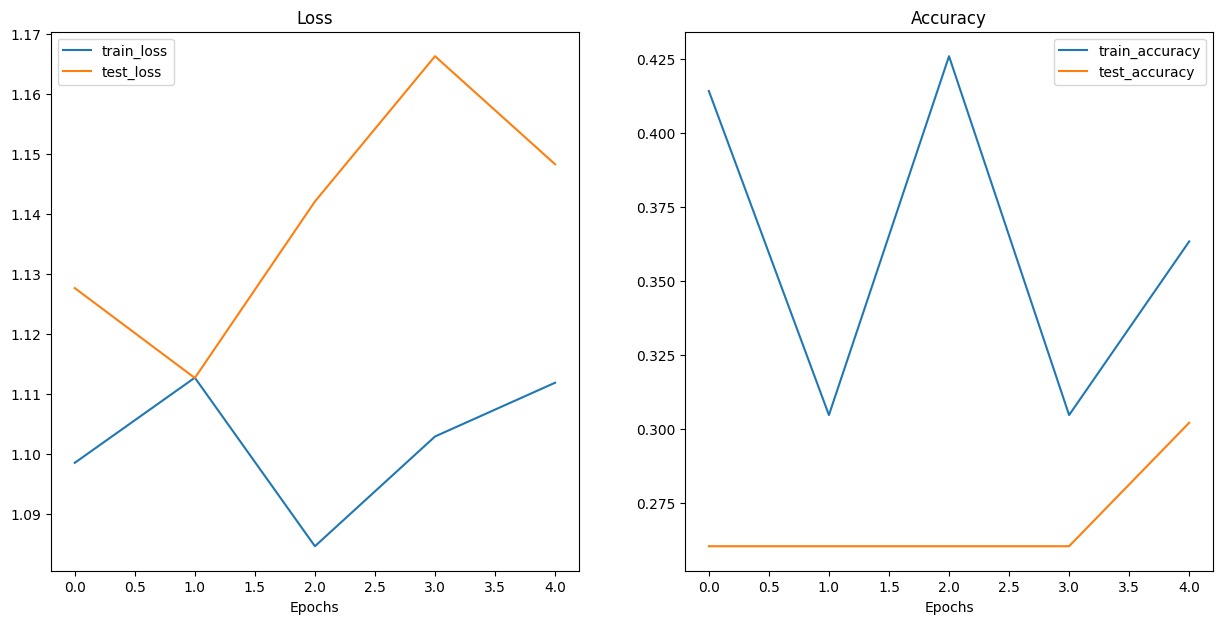

In [202]:
plot_loss_curves(model_0_results)

### 8.1 How to deal with overfitting

### 8.2 How to deal with underfitting 

24:15

## 9. Model 1: TinyVGG with Data Augmentation
### 9.1 Create transform with data augmentation

In [203]:
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

### 9.2 Create train and test `Dataset`'s and `DataLoader`'s

In [204]:
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transforms)

train_data_augmented, test_data_simple


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [205]:
train_dir

WindowsPath('data/pizza_steak_sushi/train')

In [206]:
import os 
BATCH_SIZE = 32 
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)
train_data_augmented, test_dataloader

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 <torch.utils.data.dataloader.DataLoader at 0x2c73eb292e0>)

### 9.3 Construct and train Model 1

In [207]:
# Create model_1 and send it to the target device
torch.manual_seed(42)
# Sets a fixed seed so model initialization is reproducible.

model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)
).to(device)
# Builds a TinyVGG model and moves it to CPU/GPU.

model_1
# Displays the model architecture for verification.


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [208]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_1
model_1_results = train(model=model_1, 
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

 20%|██        | 1/5 [00:24<01:39, 24.83s/it]

Epoch: 1 | train_loss: 1.1066 | train_acc: 0.2500 | test_loss: 1.1010 | test_acc: 0.2604


 40%|████      | 2/5 [00:46<01:08, 22.77s/it]

Epoch: 2 | train_loss: 1.0810 | train_acc: 0.4258 | test_loss: 1.1274 | test_acc: 0.2604


 60%|██████    | 3/5 [01:07<00:44, 22.15s/it]

Epoch: 3 | train_loss: 1.0792 | train_acc: 0.4258 | test_loss: 1.1560 | test_acc: 0.2604


 80%|████████  | 4/5 [01:29<00:21, 21.94s/it]

Epoch: 4 | train_loss: 1.1257 | train_acc: 0.3047 | test_loss: 1.1618 | test_acc: 0.2604


100%|██████████| 5/5 [01:52<00:00, 22.52s/it]

Epoch: 5 | train_loss: 1.0849 | train_acc: 0.4258 | test_loss: 1.1545 | test_acc: 0.2604
Total training time: 112.579 seconds


### 9.4 Plot the loss curves of Model 1

In [209]:
model_1_results

{'train_loss': [1.106576070189476,
  1.081037424504757,
  1.0791797414422035,
  1.1257036477327347,
  1.0849308744072914],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.42578125],
 'test_loss': [1.101004679997762,
  1.12736980120341,
  1.1560288468996684,
  1.1618163386980693,
  1.1545380155245464],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667]}

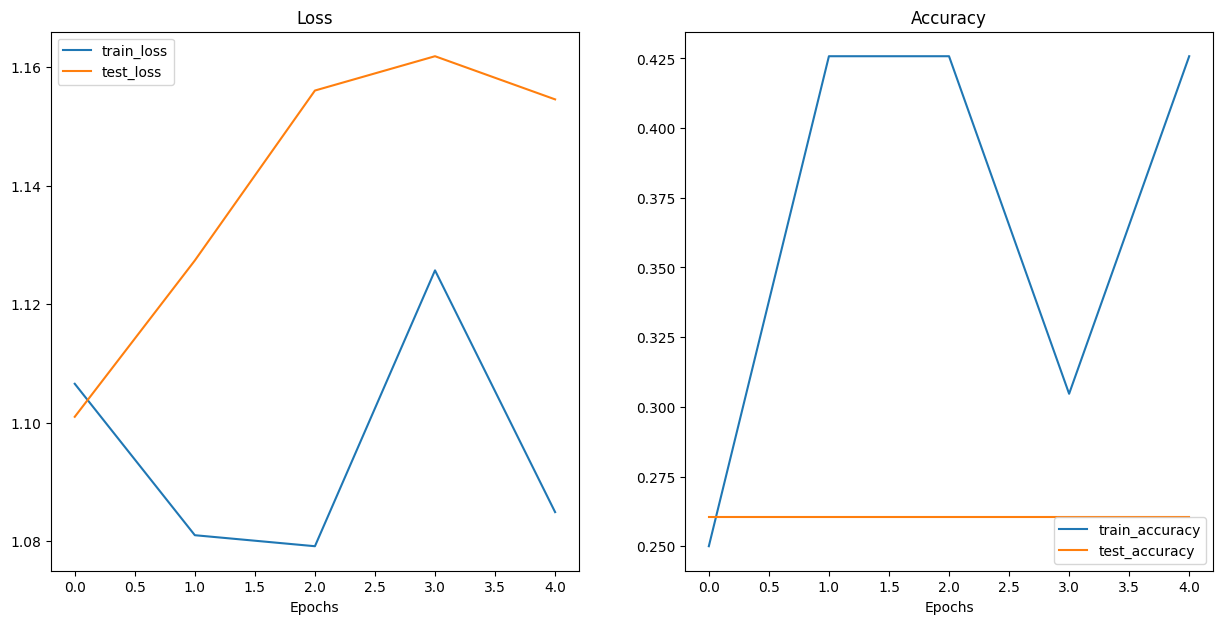

In [210]:
plot_loss_curves(model_1_results)

## 10. Compare model results

In [211]:
import pandas as pd 
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.098547,0.414062,1.127672,0.260417
1,1.112739,0.304688,1.112693,0.260417
2,1.084652,0.425781,1.142101,0.260417
3,1.102939,0.304688,1.166310,0.260417
4,1.111900,0.363281,1.148301,0.302083


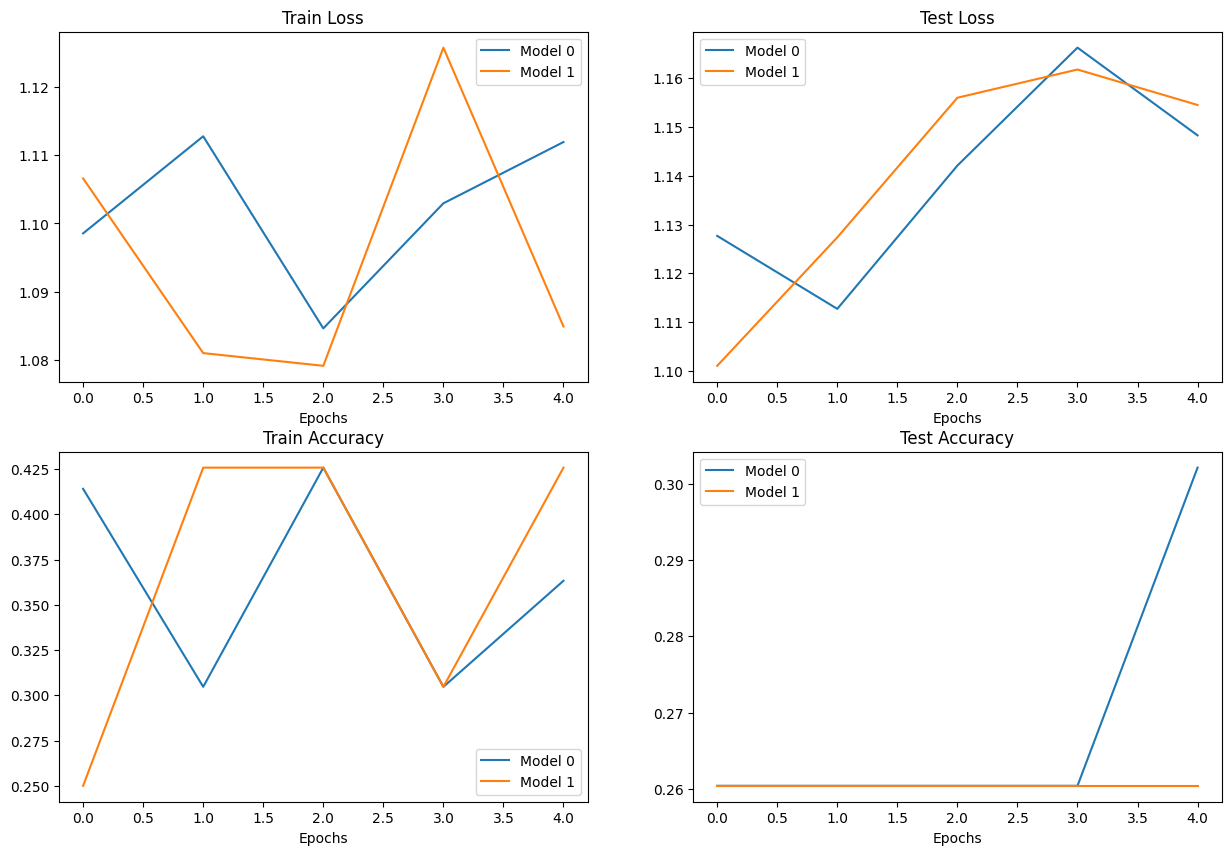

In [212]:
# Setup a plot 
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

## 11. Make a prediction on a custom image

1:00:43:00

## 11. Make a prediction on a custom image

In [213]:
import requests 
# Imports the requests library to download the image from a URL.

custom_image_path = data_path / "04-pizza-dad.jpeg"
# Defines the local file path where the image should be saved.

if not custom_image_path.is_file():
    # Checks if the image file does NOT already exist.

    with open(custom_image_path, "wb") as f:
        # Opens the file in write‑binary mode to save downloaded bytes.

        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        # Downloads the image from the GitHub URL.

        print(f"Downloading {custom_image_path}...")
        # Logs that the image is being downloaded.

        f.write(request.content)
        # Writes the downloaded image bytes to the file.

else:
    print(f"{custom_image_path} already exists, skipping download.")
    # Logs that the file already exists and avoids re-downloading.


data\04-pizza-dad.jpeg already exists, skipping download.


### 11.1 Loading in a custom image with PyTorch

In [214]:
import torchvision 
# Imports torchvision to access image loading utilities.

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
# Loads the image as a uint8 tensor in [C, H, W] format.

print(f"Custom image tensor:\n{custom_image_uint8}\n")
# Prints the raw tensor values for inspection.

print(f"Custom image shape: {custom_image_uint8.shape}\n")
# Prints the tensor shape (channels, height, width).

print(f"Custom image dtype: {custom_image_uint8}")
# Prints the tensor datatype to confirm it's uint8.


Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 4032, 3024])

Custom image dty

In [215]:
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

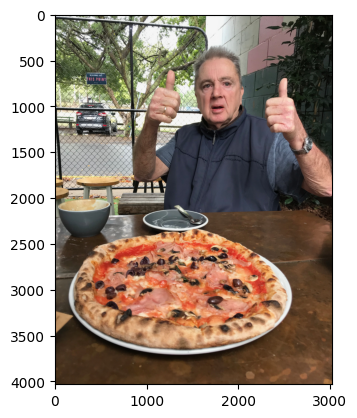

In [ ]:
plt.imshow(custom_image_uint8.permute(1,2,0))

### 11.2 Predicting on custom images with a trained PyTorch model


In [ ]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)
# Loads the image as a float32 tensor instead of uint8 for model compatibility.

custom_image = custom_image / 255.
# Normalizes pixel values from [0, 255] → [0.0, 1.0].

print(f"Custom image tensor:\n{custom_image}\n")
# Prints the normalized tensor values.

print(f"Custom image shape: {custom_image.shape}\n")
# Prints the tensor shape (channels, height, width).

print(f"Custom image dtype: {custom_image.dtype}")
# Prints the tensor datatype to confirm it's float32.


Custom image tensor:
tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..

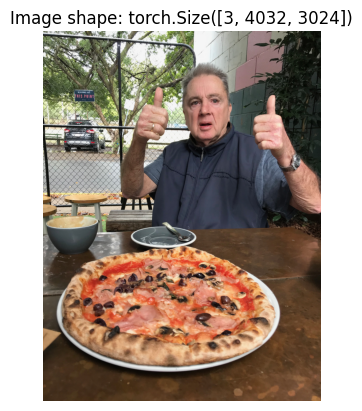

In [ ]:
plt.imshow(custom_image.permute(1,2,0))
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False);

In [ ]:
custom_image_transform = transforms.Compose([
    transforms.Resize((64,64)),
])

custom_image_transformed = custom_image_transform(custom_image)

print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 4032, 3024])
New shape: torch.Size([3, 64, 64])


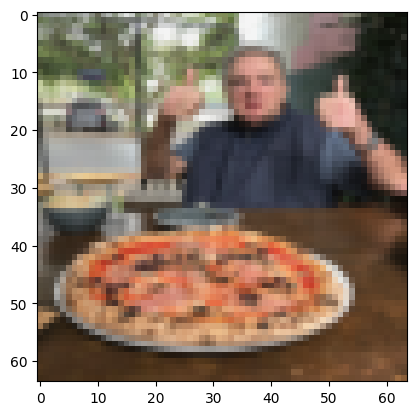

In [ ]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [216]:
model_1.eval()
with torch.inference_mode():
    custom_imagae_pred = model_1(custom_image_transformed)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

In [ ]:
model_1.eval()
with torch.inference_mode():
    custom_imagae_pred = model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

In [ ]:
model_1.eval()
with torch.inference_mode():
    # Add an extra dimension to image
    custom_image_transformed_with_batch_size = custom_image_transformed.unsqueeze(dim=0)
    
    # Print out different shapes
    print(f"Custom image transformed shape: {custom_image_transformed.shape}")
    print(f"Unsqueezed custom image shape: {custom_image_transformed_with_batch_size.shape}")
    
    # Make a prediction on image with an extra dimension
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(dim=0).to(device))

Custom image transformed shape: torch.Size([3, 64, 64])
Unsqueezed custom image shape: torch.Size([1, 3, 64, 64])


1:01:14:00

In [ ]:
custom_image_pred 

tensor([[ 0.1312, -0.0163, -0.2038]])

In [ ]:
print(f"Prediction logits: {custom_image_pred}")

custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
print(f"Prediction probabilities: {custom_image_pred_probs}")

custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
print(f"Prediction label: {custom_image_pred_label}")

Prediction logits: tensor([[ 0.1312, -0.0163, -0.2038]])
Prediction probabilities: tensor([[0.3879, 0.3347, 0.2775]])
Prediction label: tensor([0])


### 11.3 Putting custom image prediction together: building a function

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str]= None,
                        transform=None, 
                        device: torch.device= device):
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    target_image = target_image/255. 

    if transform:
        target_image = transform(target_image)
    
    model.to(device)

    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(dim=0)

        target_image_pred = model(target_image.to(device))
    
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f} "
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

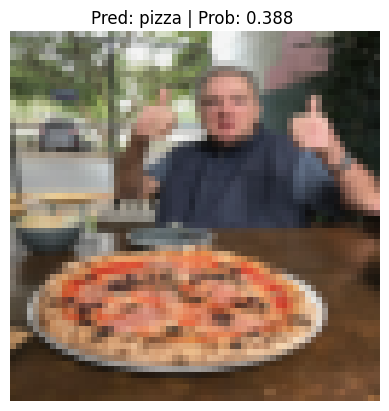

In [ ]:
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)